# Часть 2: Исследовательский анализ данных в Python и проверка гипотез. Выполнение

Мы создали дашборд, с его помощью можно увидеть, что с наступлением осени увеличилось количество заказов, однако у средней стоимости был тренд к снижению.

Коллеги из продуктовой команды просят провести исследовательский анализ данных в Python, чтобы выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

Проведем исследовательский анализ данных, чтобы дать ответы на вопросы коллег. В ходе проекта буедем активно работать с категориями событий, рассчитывать среднюю выручку с заказа и продажи одного билета в рублях, а также изучать распределение значений по категориям и периодам времени.

- Автор: Artem Sokolskii
- Дата: 16.06.2026

## Цели и задачи проекта


**Цель проекта**: Провести исследовательский анализ данных сервиса Яндекс.Афиша, выяснить причины изменения пользовательского спроса, разобраться, какие события стали привлекать больше зрителей, какие организаторы и площадки вышли в лидеры, а также понять, отличается ли активность пользователей мобильных устройств от активности клиентов, бронирующих билеты со стационарного компьютера

**Содержимое проекта:**

1. Знакомство с данными - загрузка, первичный осмотр, проверка полноты и качества данных.
2. Предобработка данных - удаление пропусков и дубликатов, фильтрация выбросов, приведение типов, конвертация валюты, создание новых признаков.
3. Исследовательский анализ - сезонная динамика заказов, сравнение летнего и осеннего спроса по категориям, анализ изменения средней стоимости билета.
4. Осенняя активность пользователей - дневная динамика, недельная цикличность, сравнение активности по буднеям и выходным.
5. Регионы и партнёры - распределение заказов и мероприятий по регионам и партнерам.
6. Статистическая проверка гипотез - проверка двух гипотез о различиях в поведении мобильных и пользователей пк с помощью теста Манна-Уитни.
7. Общий вывод и рекомендации - итоговые результаты проекта и рекомендации для продуктовой команды.

## **Описание данных**

В проекте будут использованы данные о бронировании билетов сервиса Яндекс Афиша за период с 1 июня по 31 октября 2024 года:



Первый датасет final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета соответствуют таблице purchases.

**Описание данных датасета `final_tickets_orders_df.csv`:**
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
- days_since_prev — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.


Второй датасет final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.

**Описание данных датасета `final_tickets_events_df.csv`:**
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

Третий датасет final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге.

**Описание данных датасета `final_tickets_tenge_df.csv`:**
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).

## Загрузка данных и знакомство с ними

In [1]:
# Импорт библиотеки pandas для работы с данными
import pandas as pd

# Импорт matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импорт stats из scipy для статистических тестов
from scipy import stats

# Импорт seaborn для улучшенной визуализации
import seaborn as sns

In [2]:
# Выгружаем данные в переменные
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')

events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
# Выводим первые строки датафрейма orders на экран
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выводим информацию о датафрейме orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [5]:
# Выводим первые строки датафрейма events на экран
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
# Выводим информацию о датафрейме events
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [7]:
# Выводим первые строки датафрейма tenge на экран
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
# Выводим информацию о датафрейме tenge
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


**Промежуточный вывод:**

Предоставленные данные имеют достаточный объём для анализа:
- Данные успешно загружены из трех источников
- В столбце days_since_prev обнаружены пропуски, в остальных столбцах пропусков нет.
- Столбцы с датами (created_dt_msk, created_ts_msk) необходимо привести к типу datetime
- Требуется конвертация в данных из тенге в рубли

## Предобработка данных и подготовка их к исследованию

In [9]:
# Объединяем таблицы orders и events по event_id (left join сохраняет все заказы)
df = orders.merge(events, on='event_id', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

In [10]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len(temp)

290849

In [11]:
# Проверяем, есть ли пропуски
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64

In [12]:
# Удаляем пропуски в event_name
df = df.dropna(subset = ['event_name'])
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

In [13]:
# Проверяем, есть ли пропуски
tenge.isna().sum()

data       0
nominal    0
curs       0
cdx        0
dtype: int64

Проверим, встречаются ли значения, которые могут обозначать пропуски в данных или отсутствие информации для категориальных значений

In [14]:
# Проверяем уникальные значения
df['cinema_circuit'].value_counts()

нет           289213
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

In [15]:
df['age_limit'].value_counts()

16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64

In [16]:
df['service_name'].value_counts()

Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                   67
Цвет и б

Посмотрим на распределение и наличие выбросов для количественных значений, а именно для столбцов 'revenue' и 'tickets_count'

In [17]:
df['revenue'].describe()

count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
25%         116.850000
50%         356.010000
75%         810.130000
max       81174.540000
Name: revenue, dtype: float64

In [18]:
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Визуализируем распределение числовых значений

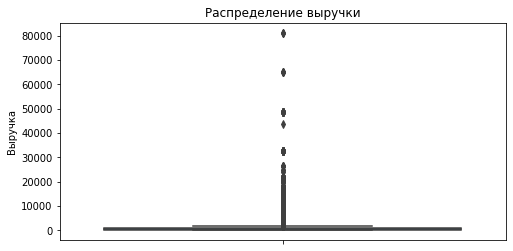

In [19]:
plt.figure(figsize = (8, 4))

sns.boxplot(y = df['revenue'])

plt.title('Распределение выручки')
plt.ylabel('Выручка')
plt.show()

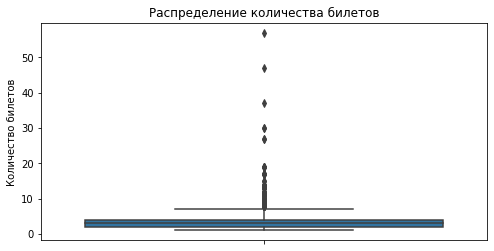

In [20]:
plt.figure(figsize = (8, 4))

sns.boxplot(y = df['tickets_count'])

plt.title('Распределение количества билетов')
plt.ylabel('Количество билетов')
plt.show()

In [21]:
# Фильтурем данные по 'revenue' и 'tickets_count' по 99-му процентилю 
# df = df[(df['revenue'] <= df['revenue'].quantile(0.99)) & (df['tickets_count'] <= df['tickets_count'].quantile(0.99))]

In [22]:
# Разделим df по валюте, отфильтруем значения по 99-му процентилю и объединим обратно
df_rub = df[df['currency_code'] == 'rub']
df_kzt = df[df['currency_code'] == 'kzt']

df_rub = df_rub[df_rub['revenue'] <= df_rub['revenue'].quantile(0.99)]
df_rub = df_rub[df_rub['tickets_count'] <= df_rub['tickets_count'].quantile(0.99)]

df_kzt = df_kzt[df_kzt['revenue'] <= df_kzt['revenue'].quantile(0.99)]
df_kzt = df_kzt[df_kzt['tickets_count'] <= df_kzt['tickets_count'].quantile(0.99)]

df = pd.concat([df_rub, df_kzt])

In [23]:
# Фильтруем по валюте 'rub'
df_rub = df[df['currency_code'] == 'rub']
print(df_rub['revenue'].describe()) 

print()

print(df_rub['tickets_count'].describe())

count    282562.000000
mean        510.561628
std         500.828305
min         -90.760000
25%         112.020000
50%         340.490000
75%         781.720000
max        2570.800000
Name: revenue, dtype: float64

count    282562.000000
mean          2.735127
std           1.136176
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           6.000000
Name: tickets_count, dtype: float64


In [24]:
# Фильтруем по валюте 'kzt'
df_tenge = df[df['currency_code'] == 'kzt']
print(df_tenge['revenue'].describe())

print()

print(df_tenge['tickets_count'].describe())

count     5040.000000
mean      4893.669063
std       4742.680176
min          0.000000
25%        515.350000
50%       3698.830000
75%       7397.660000
max      17617.240000
Name: revenue, dtype: float64

count    5040.000000
mean        2.748413
std         1.101784
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: tickets_count, dtype: float64


In [25]:
# Проверяем на явные дубликаты
duplicates_count = df.duplicated().sum()
duplicates_count

0

In [26]:
# Проверяем на неявные дубликаты
dup_columns = ['user_id', 'created_ts_msk', 'tickets_count', 'event_id', 'revenue']

df.duplicated(subset = dup_columns).sum()

43

Обнаружили 44 дубликатов по столбцам 'user_id', 'created_ts_msk', 'event_id', 'revenue', скорее всего это одна покупка, удалим эти строки

In [27]:
df = df.drop_duplicates(subset = dup_columns, keep = 'first')

Снизим размерность для численных значений датасета

In [28]:
for i in df.select_dtypes(include = ['int64', 'float64']).columns:
    df[i] = pd.to_numeric(df[i], downcast='integer')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287559 entries, 0 to 290727
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                287559 non-null  int32  
 1   user_id                 287559 non-null  object 
 2   created_dt_msk          287559 non-null  object 
 3   created_ts_msk          287559 non-null  object 
 4   event_id                287559 non-null  int32  
 5   cinema_circuit          287559 non-null  object 
 6   age_limit               287559 non-null  int8   
 7   currency_code           287559 non-null  object 
 8   device_type_canonical   287559 non-null  object 
 9   revenue                 287559 non-null  float64
 10  service_name            287559 non-null  object 
 11  tickets_count           287559 non-null  int8   
 12  total                   287559 non-null  float64
 13  days_since_prev         265858 non-null  float64
 14  event_name          

In [29]:
# Приведем даты к верному типу данных
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
tenge['data'] = pd.to_datetime(tenge['data'])

Приведем выручку с заказов к единой валюте и создадим несколько новых столбцов

In [30]:
# Объединяем df с tenge 
df = df.merge(tenge[['data', 'curs']], left_on = 'created_dt_msk', right_on = 'data', how = 'left')

In [31]:
# Создаем столбец revenue_rub
df['revenue_rub'] = df['revenue']

# Рассчитываем значения для revenue_rub
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = df.loc[df['currency_code'] =='kzt', 'revenue'] * df.loc[df['currency_code'] == 'kzt', 'curs'] / 100

In [32]:
# Создаем столбец с выручкой с продажи одного билета
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

In [33]:
df['month'] = df['created_dt_msk'].dt.month

In [34]:
# Создаем и применяем функцию для столбца с информацией о сезонности
def seasons(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4 ,5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'
    
df['season'] = df['month'].apply(seasons)

In [35]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2),
      '\n', "Доля срезанных данных", round((a-b)/a, 3))

 Было строк в исходном датасете 290849 
 Осталось строк в датасете после обработки 287559 
 Удалено строк в датасете после обработки 3290 
 Процент потерь 1.13 
 Доля срезанных данных 0.011


**Промежуточный вывод:**

- Исходные датафреймы объединены по event_id, удалено 238 пропусков в данных о событиях.
- Явные дубликаты отсутствуют, удалено 44 неявных дубликата (повторные записи одной покупки).
- Для столбцов revenue и tickets_count проведена фильтрация по 99-му процентилю для исключения выбросов.
- Типы данных приведены к корректным: даты - к datetime, числовые - к оптимальным форматам с понижением размерности.
- Созданы новые столбцы: revenue_rub (конвертация тенге в рубли по курсу), one_ticket_revenue_rub (выручка за один билет), month (месяц заказа), season (сезон).
- Данные готовы к исследовательскому анализу (287 473 строки, пропуски остались только в days_since_prev).

## Исследовательский анализ данных

Для каждого месяца найдем количество заказов и визуализируем

In [36]:
orders_per_month = df.groupby('month')['order_id'].count()
orders_per_month

month
6     34147
7     40375
8     44514
9     69310
10    99213
Name: order_id, dtype: int64

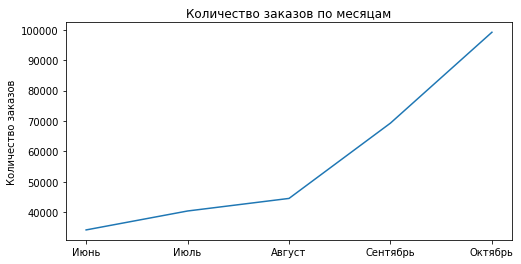

In [37]:
plt.figure(figsize = (8, 4))

orders_per_month.plot(kind = 'line')

plt.title('Количество заказов по месяцам')
plt.xlabel('')
plt.ylabel('Количество заказов')
plt.xticks(orders_per_month.index, ['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь'])
plt.show()

Для осеннего и летнего периода сравним распределение заказов билетов

In [38]:
summer_df = df[df['season'] == 'Лето']
autumn_df = df[df['season'] == 'Осень']
autumn_df = df[df['season'] == 'Осень'].copy()

In [39]:
# Создадим датафрейм на основе долей заказов летнего и осеннего сезонов по типу мероприятия

events_summer = summer_df.groupby('event_type_main')['order_id'].count()
events_autumn = autumn_df.groupby('event_type_main')['order_id'].count()

events_summer_sum = events_summer.sum()
events_autumn_sum = events_autumn.sum()

summer_share = events_summer / events_summer_sum
autumn_share = events_autumn / events_autumn_sum

shares_df = pd.DataFrame({
    'Лето': summer_share,
    'Осень': autumn_share
})

print(shares_df)

                     Лето     Осень
event_type_main                    
выставки         0.020296  0.014455
другое           0.271338  0.196739
концерты         0.426442  0.372210
спорт            0.025236  0.111961
стендап          0.053312  0.041080
театр            0.201082  0.253532
ёлки             0.002293  0.010022


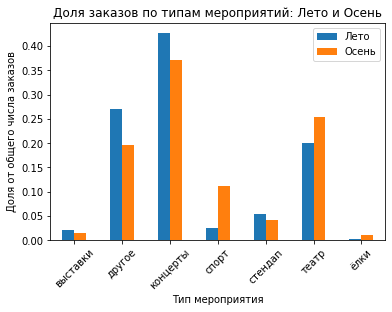

In [40]:
# Строим визуализацию распределения заказов по типам мероприятий
shares_df.plot(kind = 'bar')

plt.title('Доля заказов по типам мероприятий: Лето и Осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля от общего числа заказов')
plt.xticks(rotation = 45)

plt.show()

In [41]:
summer_ticket = summer_df.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_ticket = autumn_df.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

tickets_df = pd.DataFrame({
    'Лето': summer_ticket,
    'Осень': autumn_ticket
})

print(tickets_df)
print('\n')
print(f'Изменение осенних значений по сравнению с летними (в %): {(tickets_df["Осень"] / tickets_df["Лето"] - 1) * 100}')

                       Лето       Осень
event_type_main                        
выставки          86.416198   90.603610
другое            77.397654   76.059694
концерты         304.800056  268.383537
спорт             50.744650   49.987756
стендап          218.518107  231.124973
театр            214.179496  175.991603
ёлки             271.436176  229.564210


Изменение осенних значений по сравнению с летними (в %): event_type_main
выставки     4.845634
другое      -1.728683
концерты   -11.947675
спорт       -1.491574
стендап      5.769255
театр      -17.829854
ёлки       -15.426081
dtype: float64


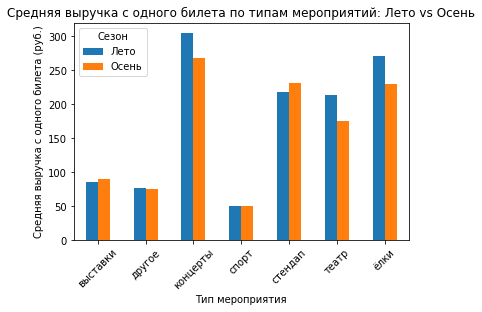

In [42]:
tickets_df.plot(kind = 'bar')

plt.title('Средняя выручка с одного билета по типам мероприятий: Лето vs Осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка с одного билета (руб.)')
plt.legend(title='Сезон')
plt.xticks(rotation=45)

plt.show()

**Вывод по изменению распределений:**

- С наступлением осени тенденция заказов изменилась: доля событий в театре выросла с 20% до 25%, а в спорте с 2% до 11%, при этом доля концертов снизилась с 41% до 37%, также осенью выросла доля ёлок с 0,2% до 1%.
- Средняя стоимость одного билета снизилась в большинстве категорий. Наиболее сильное падение зафиксировано в театрах (–17,8%) и ёлках (–14,8%), в то же время в категориях стендап (+5,1%) и выставки (+5,4%) наблюдается небольшой рост стоимости.

Таким образом, снижение среднего чека осенью связано с двумя факторами:

- Билеты внутри большинства категорий стали дешевле (особенно в театрах).
- Произошёл сдвиг спроса в сторону более бюджетных событий (категории театры, спорт) и снижение доли дорогих концертов.

Проанализируем осеннюю активность пользователей

In [43]:
# Считаем количество заказов в день
orders_count = autumn_df.groupby('created_dt_msk')['order_id'].count()
orders_count

created_dt_msk
2024-09-01    1327
2024-09-02    1380
2024-09-03    5113
2024-09-04    1772
2024-09-05    1940
              ... 
2024-10-27    2849
2024-10-28    2836
2024-10-29    2833
2024-10-30    2927
2024-10-31    5956
Name: order_id, Length: 61, dtype: int64

In [44]:
# Считаем количество уникальных пользователей в день
dau = autumn_df.groupby('created_dt_msk')['user_id'].nunique()
dau

created_dt_msk
2024-09-01     564
2024-09-02     574
2024-09-03     778
2024-09-04     685
2024-09-05     739
              ... 
2024-10-27    1034
2024-10-28     985
2024-10-29     998
2024-10-30    1039
2024-10-31    1272
Name: user_id, Length: 61, dtype: int64

In [45]:
# Считаем среднее количество заказов в день
avg_orders = orders_count.values / dau.values
avg_orders

array([2.35283688, 2.40418118, 6.57197943, 2.58686131, 2.62516915,
       2.45833333, 2.46347607, 2.38912134, 2.68421053, 2.64790576,
       2.71970624, 2.70314319, 2.88054968, 2.77619048, 2.75384615,
       2.76101469, 2.86845466, 2.97810219, 3.06436234, 3.0221519 ,
       2.73938002, 2.32780612, 2.9113608 , 2.79915433, 2.75779626,
       2.76116071, 2.71442591, 2.71243243, 2.61978546, 2.61538462,
       6.62966333, 2.80240175, 2.78151261, 3.03615702, 2.76020408,
       2.73453318, 3.        , 2.71754933, 2.61929461, 2.93007663,
       2.87617261, 2.72201139, 2.64423077, 2.83608147, 3.55232029,
       2.64504171, 2.91439323, 3.30681818, 2.78884826, 2.80864865,
       2.92102564, 2.8622449 , 2.83219512, 3.09959759, 3.71160131,
       3.12411348, 2.75531915, 2.87918782, 2.83867735, 2.81713186,
       4.68238994])

In [46]:
# Считаем среднюю стоимость билета в день
sum_revenues = autumn_df.groupby('created_dt_msk')['revenue'].sum()
sum_tickets = autumn_df.groupby('created_dt_msk')['tickets_count'].sum()
avg_tickets = sum_revenues.values / sum_tickets.values
avg_tickets

array([197.30280258, 210.03117441,  80.68495882, 198.47152723,
       213.15341124, 204.02500693, 206.24219344, 191.05934491,
       157.78573266, 191.5484287 , 186.44088756, 191.16435046,
       182.99157866, 183.01224393, 200.56894946, 204.39932761,
       198.75150389, 186.66798636, 175.55496832, 169.98718669,
       197.09065954, 203.03810529, 184.72680169, 165.75711834,
       199.44831303, 197.6803926 , 203.84166193, 196.43227479,
       204.69328325, 201.67319693,  90.72768461, 191.73121507,
       205.58210541, 199.81471128, 204.18373394, 209.39754551,
       191.99521308, 192.8665054 , 203.6684629 , 198.48483704,
       205.70342402, 211.3366182 , 211.34604692, 186.84432331,
       154.44605863, 196.07470968, 184.40297398, 186.20616895,
       200.04356601, 207.63380546, 189.33577246, 185.40990904,
       192.48982048, 187.00806913, 184.54853843, 170.74564851,
       187.54504513, 172.65387765, 172.54496977, 188.62992187,
       156.14396729])

In [47]:
# Создадим сводную таблицу по вычисленным значениям
autumn_daily_stats = pd.DataFrame({
    'orders_count': orders_count,
    'dau': dau,
    'avg_orders_per_user': avg_orders,
    'avg_ticket_price': avg_tickets
})
autumn_daily_stats

,orders_count,dau,avg_orders_per_user,avg_ticket_price
created_dt_msk,,,,
2024-09-01,1327,564,2.352837,197.302803
2024-09-02,1380,574,2.404181,210.031174
2024-09-03,5113,778,6.571979,80.684959
2024-09-04,1772,685,2.586861,198.471527
2024-09-05,1940,739,2.625169,213.153411
...,...,...,...,...
2024-10-27,2849,1034,2.755319,187.545045
2024-10-28,2836,985,2.879188,172.653878
2024-10-29,2833,998,2.838677,172.544970


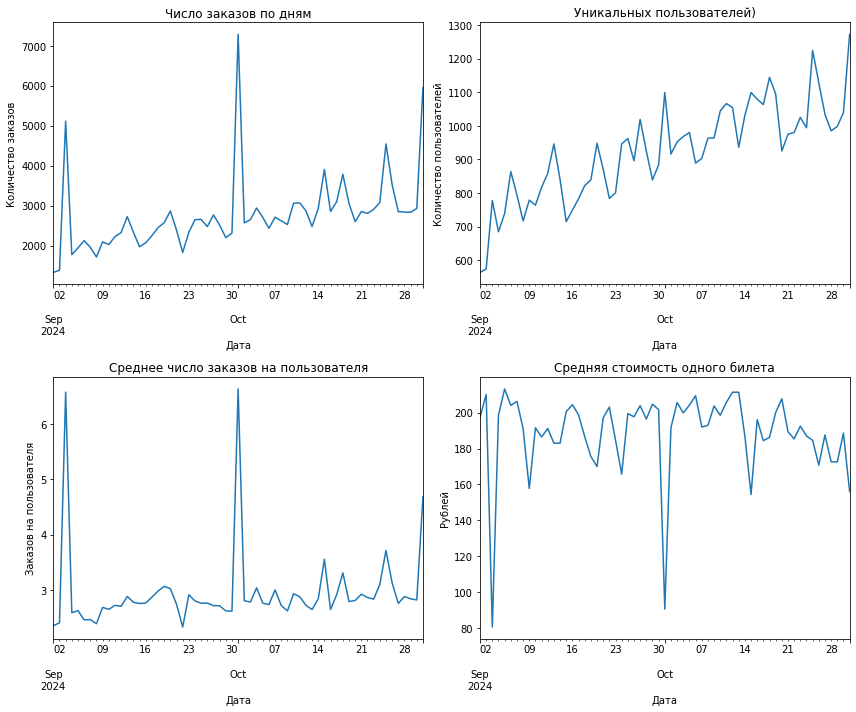

In [48]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))

# Число заказов по дням
autumn_daily_stats['orders_count'].plot(kind='line', ax=axes[0, 0])

# DAU по дням
autumn_daily_stats['dau'].plot(kind='line' ,ax=axes[0, 1])

# Среднее число заказов на пользователя
autumn_daily_stats['avg_orders_per_user'].plot(kind='line', ax=axes[1, 0])

# Средняя стоимость одного билета
autumn_daily_stats['avg_ticket_price'].plot(kind='line', ax=axes[1, 1])

# Заголовки для каждого графика
axes[0, 0].set_title('Число заказов по дням')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].set_xlabel('Дата')

axes[0, 1].set_title('Уникальных пользователей)')
axes[0, 1].set_ylabel('Количество пользователей')
axes[0, 1].set_xlabel('Дата')

axes[1, 0].set_title('Среднее число заказов на пользователя')
axes[1, 0].set_ylabel('Заказов на пользователя')
axes[1, 0].set_xlabel('Дата')

axes[1, 1].set_title('Средняя стоимость одного билета')
axes[1, 1].set_ylabel('Рублей')
axes[1, 1].set_xlabel('Дата')

plt.tight_layout()
plt.show()

Изучим недельную цикличность

In [49]:
# Отделяем столбец created_dt_msk от индексов и выделяем из него день неделт
autumn_daily_stats = autumn_daily_stats.reset_index()
autumn_daily_stats['week_day'] = autumn_daily_stats['created_dt_msk'].dt.day_name()

In [50]:
# Рассчитываем на каждый день недели общее количество заказов
autumn_days_orders = autumn_daily_stats.groupby('week_day')['orders_count'].sum()
autumn_days_orders

week_day
Friday       24811
Monday       21500
Saturday     21332
Sunday       19385
Thursday     27149
Tuesday      31475
Wednesday    22871
Name: orders_count, dtype: int64

In [51]:
# Рассчитываем на каждый день недели среднее количество уникальных покупателей
autumn_days_dau = autumn_daily_stats.groupby('week_day')['dau'].mean()
autumn_days_dau

week_day
Friday       1022.375000
Monday        853.444444
Saturday      960.750000
Sunday        822.555556
Thursday      962.000000
Tuesday       934.444444
Wednesday     923.222222
Name: dau, dtype: float64

In [52]:
# Рассчитываем на каждый день недели среднее количество заказов на покупателя
autumn_days_avg_order = autumn_daily_stats.groupby('week_day')['avg_orders_per_user'].mean()
autumn_days_avg_order

week_day
Friday       3.000776
Monday       2.779161
Saturday     2.760832
Sunday       2.598459
Thursday     3.062423
Tuesday      3.720883
Wednesday    2.750948
Name: avg_orders_per_user, dtype: float64

In [53]:
# Рассчитываем на каждый день недели среднюю стоимость билета
autumn_days_avg_ticket = autumn_daily_stats.groupby('week_day')['avg_ticket_price'].mean()
autumn_days_avg_ticket

week_day
Friday       192.139785
Monday       188.827269
Saturday     196.135867
Sunday       201.398325
Thursday     189.908342
Tuesday      159.193015
Wednesday    193.735872
Name: avg_ticket_price, dtype: float64

In [54]:
# Создаем датафрейм с вычисленными значениями
weekday_df = pd.DataFrame({
    'orders_count': autumn_days_orders,
    'dau': autumn_days_dau,
    'avg_orders': autumn_days_avg_order,
    'avg_ticket_price': autumn_days_avg_ticket
})

In [55]:
# Сортируем дни недели в правильном порядке
correct_weekday =  ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_df = weekday_df.reindex(correct_weekday)
# Посмотрим на результат
weekday_df

,orders_count,dau,avg_orders,avg_ticket_price
week_day,,,,
Monday,21500,853.444444,2.779161,188.827269
Tuesday,31475,934.444444,3.720883,159.193015
Wednesday,22871,923.222222,2.750948,193.735872
Thursday,27149,962.000000,3.062423,189.908342
Friday,24811,1022.375000,3.000776,192.139785
Saturday,21332,960.750000,2.760832,196.135867
Sunday,19385,822.555556,2.598459,201.398325


In [56]:
# Считаем средние значения для будней
weekday_avg = weekday_df.loc[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']].mean()

# Считаем средние значения для выходных
weekend_avg = weekday_df.loc[['Saturday', 'Sunday']].mean()


difference_df = pd.DataFrame({
    'Будни': weekday_avg,
    'Выходные': weekend_avg,
    'Разница': weekend_avg - weekday_avg
})

difference_df

,Будни,Выходные,Разница
orders_count,25561.200000,20358.500000,-5202.700000
dau,939.097222,891.652778,-47.444444
avg_orders,3.062838,2.679645,-0.383193
avg_ticket_price,184.760856,198.767096,14.006240


**Промежуточный вывод:**

- В сентябре–октябре наблюдается стабильный рост спроса: DAU увеличивается с ~600 до ~1300 пользователей в день, а число заказов следует за этим трендом. Среднее число заказов держится на уровне 2,5–3,0.

- Недельная цикличность показала, что в будни оформляется больше заказов и выше DAU, однако в выходные средняя стоимость билета выше на 14,4. Это означает, что будни обеспечивают основной поток заказов, а выходные — более высокий средний чек. 

- Аномальные всплески 3 сентября и 1 октября (резкий рост заказов при падении цены) могут указывать на проведение акций.

Изучим распределение событий по регионам и партнерам

In [57]:
# Применяем функции для столбцов чтобы получить значения по регионам
region_values = df.groupby('region_name')[['order_id', 'event_id']].agg({
    'order_id': 'count',
    'event_id': 'nunique'
}).rename(columns = {
    'order_id': 'orders_count',
    'event_id': 'unique_events'
})

# Сортируем по количеству уникальных мероприятий и выводим топ-10
region_values = region_values.sort_values(by = 'unique_events', ascending = False)

In [58]:
# Создадим таблицу с относительными значениями
all_orders_count = region_values['orders_count'].sum()
all_unique_events = region_values['unique_events'].sum()

region_values['share_orders'] = region_values['orders_count'] / all_orders_count
region_values['share_events'] = region_values['unique_events'] / all_unique_events

region_values.head(10)

,orders_count,unique_events,share_orders,share_events
region_name,,,,
Каменевский регион,89635,5933,0.311710,0.265459
Североярская область,43621,3797,0.151694,0.169888
Широковская область,16164,1232,0.056211,0.055123
Светополянский округ,7500,1075,0.026082,0.048098
Речиновская область,6265,702,0.021787,0.031409
Травяная область,5036,683,0.017513,0.030559
Горицветская область,5152,551,0.017916,0.024653
Серебринская область,5586,541,0.019426,0.024206
Яблоневская область,6122,535,0.021290,0.023937


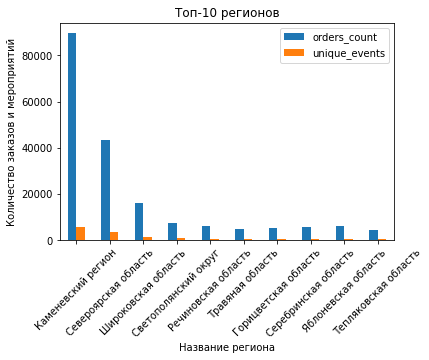

In [59]:
# Визуализация топ-10 регионов
region_values.head(10)[['orders_count', 'unique_events']].plot(
    kind='bar')
plt.title('Топ-10 регионов')
plt.xlabel('Название региона')
plt.ylabel('Количество заказов и мероприятий')
plt.xticks(rotation=45)

plt.show()

In [60]:
# Применяем функции для столбцов чтобы получить значения по парнерам
partners_values = df.groupby('service_name')[['event_id', 'order_id', 'revenue']].agg({
    'event_id': 'nunique',
    'order_id': 'count',
    'revenue': 'sum'
}).rename(columns = {
    'event_id': 'unique_events',
    'order_id': 'order_counts',
    'revenue': 'revenue_sum'
})

# Сортируем по количеству уникальных мероприятий и выводим топ-10
partners_values = partners_values.sort_values(by = 'unique_events', ascending = False)

In [61]:
# Создадим таблицу с относительными значениями
all_unique_events = partners_values['unique_events'].sum()
all_order_counts = partners_values['order_counts'].sum()
all_revenue_sum = partners_values['revenue_sum'].sum()

partners_values['share_unique_events'] = partners_values['unique_events'] / all_unique_events
partners_values['share_order_counts'] = partners_values['order_counts'] / all_order_counts
partners_values['share_revenue_sum'] = partners_values['revenue_sum'] / all_revenue_sum

partners_values.head(10)

,unique_events,order_counts,revenue_sum,share_unique_events,share_order_counts,share_revenue_sum
service_name,,,,,,
Лови билет!,4867,40796,1.667302e+07,0.199664,0.141870,0.098708
Билеты без проблем,4241,62722,2.636870e+07,0.173983,0.218119,0.156109
Билеты в руки,3530,40270,1.319085e+07,0.144815,0.140041,0.078093
Облачко,2335,26402,1.858861e+07,0.095791,0.091814,0.110049
Лучшие билеты,1762,17732,2.720706e+06,0.072284,0.061664,0.016107
Мой билет,1297,34412,3.936290e+07,0.053208,0.119669,0.233038
Тебе билет!,1062,5190,2.962303e+06,0.043567,0.018048,0.017538
Прачечная,1026,10222,4.746811e+06,0.042091,0.035547,0.028102
Весь в билетах,855,16424,1.653235e+07,0.035075,0.057115,0.097876


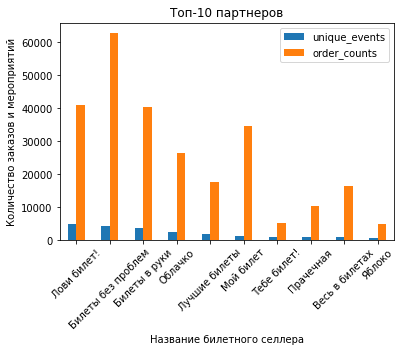

In [62]:
# Визуализация топ-10 регионов
partners_values.head(10)[['unique_events', 'order_counts']].plot(
    kind='bar')
plt.title('Топ-10 партнеров')
plt.xlabel('Название билетного селлера')
plt.ylabel('Количество заказов и мероприятий')
plt.xticks(rotation=45)

plt.show()

**Промежуточный вывод:**

- Распределение неравномерное, среди регионов лидерами являются Каменевский регион и Североярская область - на них приходится 47% всех заказов и 43% уникальных мероприятия, остальные регионы имеют доли менее 6% каждый.

- Среди партнёров выделяются «Билеты без проблем», «Лови билет!» и «Облачко» - они составляют 45% заказов и 40% выручки. При этом «Билеты без проблем» — лидер по заказам и выручке, а «Лови билет!» - по разнообразию событий.

Таким образом, можем отметить выраженную концентрацию - около половины значений установлены на нескольких регионах и партнерах

## Статистический анализ данных

В этом разделе мы проверим две гипотезы, сформулированные продуктовой командой относительно активности пользователей мобильных и пользователей пк.

Гипотеза 1: Среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей пк.

Гипотеза 2: Среднее время между заказами у пользователей мобильных приложений выше, чем у пользователей пк.

**Сначала проверим первую гипотезу**

Сформулируем нулевую и альтернативную гипотезы:

- H0 (нулевая гипотеза): Среднее количество заказов на одного мобильного пользователя равно или меньше, чем у пользователей пк.
- H1 (альтернативная гипотеза): Среднее количество заказов на одного мобильного пользователя больше, чем у пользователей пк.

In [63]:
# Посчитаем на каждого пользователей его устройства
same_users = autumn_df.groupby('user_id')['device_type_canonical'].nunique().sort_values(ascending = False)
same_users

user_id
468c4b46d324be6    2
a857d55348546b6    2
6d6447fec3ee8a5    2
6d56430f78d06af    2
6d55dd125e20d74    2
                  ..
5e73d6b56b797e7    1
5e7ded9a2c9d7a9    1
5e7f6b576bf5225    1
5e87726adee774e    1
ffff00725179321    1
Name: device_type_canonical, Length: 15805, dtype: int64

In [64]:
# Найдем пользователей которые использую оба типа устройств
same_users = same_users[same_users > 1]
same_users

user_id
468c4b46d324be6    2
a857d55348546b6    2
6d6447fec3ee8a5    2
6d56430f78d06af    2
6d55dd125e20d74    2
                  ..
e5c7cf2521c9b86    2
e5ce0cce41ae6ac    2
1b371c711084608    2
e912f424d5b2cf9    2
9e4f3ad398e1a2e    2
Name: device_type_canonical, Length: 3248, dtype: int64

In [65]:
# Удалим их из датафрейма
autumn_df = autumn_df[~autumn_df['user_id'].isin(same_users)]

In [66]:
# Сгруппируем данные за осень и переведем в таблицу
massive = autumn_df.groupby(['user_id', 'device_type_canonical'])['order_id'].count()
massive = massive.reset_index()
massive

,user_id,device_type_canonical,order_id
0,0005ca5e93f2cf4,mobile,1
1,000898990054619,mobile,2
2,000a55a418c128c,mobile,2
3,001e7037d013f0f,mobile,2
4,00245c702bc343e,mobile,2
...,...,...,...
19048,fff32fc9ad0f9f6,desktop,1
19049,fffcd3dde79eb2c,desktop,2
19050,fffcd3dde79eb2c,mobile,14
19051,fffeeb3c120cf0b,desktop,1


In [67]:
# Разделим массив данных на два по типу устройства
mobile_orders = massive[massive['device_type_canonical'] == 'mobile']['order_id'].sort_values(ascending = False)
desktop_orders = massive[massive['device_type_canonical'] == 'desktop']['order_id'].sort_values(ascending = False)
print(mobile_orders)
print('\n')
print(desktop_orders)
print('\n')
print(mobile_orders.mean())
print(desktop_orders.mean())

838      4332
1770     2119
9638     1791
4686     1782
5876     1719
         ... 
8982        1
8977        1
8972        1
8965        1
19052       1
Name: order_id, Length: 14187, dtype: int64


837      1492
9283      714
15397     635
9402      597
1769      593
         ... 
8633        1
8636        1
8654        1
8655        1
19051       1
Name: order_id, Length: 4866, dtype: int64


9.464086840064848
7.03986847513358


Для проверки гипотез используем тест Манна–Уитни, так как распределения не являются нормальными.

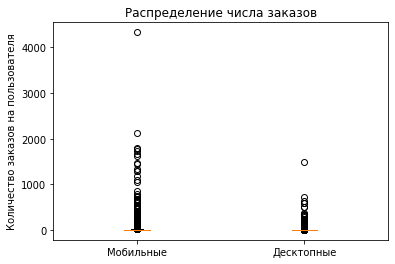

In [68]:
# Визуализируем через ящик с усами
plt.boxplot([mobile_orders, desktop_orders], labels=['Мобильные', 'Десктопные'])
plt.title('Распределение числа заказов')
plt.ylabel('Количество заказов на пользователя')
plt.show()

In [69]:
# Проверка первой гипотезы
from scipy.stats import mannwhitneyu

alpha = 0.05

stat_mw, p_value_mw = mannwhitneyu(
    mobile_orders,
    desktop_orders,
    alternative= 'greater'
)

print(f'pvalue={p_value_mw}') 

if p_value_mw > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=3.7517575005947054e-07
Нулевая гипотеза не находит подтверждения!


Мобильные пользователи статистически значимо совершают больше заказов, чем пользователи пк, это подтверждает первую гипотезу

**Проверяем вторую гипотезу**

Сформулируем нулевую и альтернативную гипотезы:

- H0: Среднее время между заказами у мобильных пользователей равно или меньше, чем у пользователей пк.
- H1: Среднее время между заказами у мобильных пользователей больше, чем у пользователей пк.

In [70]:
# Создаем таблицу без пустых строк в столбце days_since_prev
autumn_droped = autumn_df.dropna(subset = ['days_since_prev'])

In [71]:
mobile_days = autumn_droped[autumn_droped['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_days = autumn_droped[autumn_droped['device_type_canonical'] == 'desktop']['days_since_prev']

Чтобы понять, является ли эта разница статистически значимой или случайной, применяем тест Манна–Уитни к двум выборкам

In [72]:
# Проверка второй гипотезы

alpha = 0.05

stat_mw, p_value_mw = mannwhitneyu(
    mobile_days,
    desktop_days,
    alternative= 'greater'
)

print(f'pvalue={p_value_mw}') 

if p_value_mw > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=5.0042812319194404e-92
Нулевая гипотеза не находит подтверждения!


Это означает, что мобильные пользователи действительно ждут дольше между заказами, чем пользователи, использующие пк.

**Промежуточный вывод:**

- Гипотеза 1 (количество заказов на пользователя):  
  p-value < 0.05 - гипотеза подтверждена.  
  Мобильные пользователи совершают статистически значимо больше заказов, чем десктопные.

- Гипотеза 2 (время между заказами): 
  p-value < 0.05 - гипотеза подтверждена.  
  Мобильные пользователи в среднем ждут дольше между заказами, чем десктопные.

Осенью мобильные пользователи активнее в плане количества покупок и реже возвращаются за новыми заказами по сравнению с пользователями пк.

## Общий вывод и рекомендации

**Данные:**

В ходе проекта были проанализированы данные о бронированиях билетов на сервисе ЯндексАфиша за период с 1 июня по 31 октября 2024 года. После объединения трёх датасетов, очистки от пропусков и дубликатов, фильтрации выбросов по 99-му процентилю и конвертации валюты в рубли итоговый датафрейм содержал 287 559 строки, готовые к анализу.

**Основные результаты анализа:**

1. **Сезонная динамика:** С наступлением осени количество заказов выросло более чем в 3 раза. При этом средняя стоимость одного билета снизилась, особенно в театрах и на ёлках. Это связано как с удешевлением билетов внутри категорий, так и со сдвигом спроса в сторону более бюджетных событий (театры, спорт) и снижением доли дорогих концертов.

2. **Осенняя активность:** DAU вырос с ~600 до ~1300 пользователей в день. Среднее число заказов на пользователя стабильно держится на уровне 2,5–3,0. В выходные дни фиксируется более высокая средняя стоимость билета, чем в будни, что говорит о том, что в выходные пользователи выбирают более дорогие мероприятия.

3. **Регионы и партнёры:** Явные лидеры - Каменевский регион и Североярская область (47% заказов, 43% мероприятий). Среди партнёров выделяются «Билеты без проблем» (лидер по заказам и выручке), «Лови билет!» (лидер по разнообразию мероприятий) и «Облачко». На топ-3 партнёров приходится 45% заказов и 40% выручки.

4. **Статистический анализ данных** Обе гипотезы подтверждены. Мобильные пользователи осенью совершают статистически значимо больше заказов и ждут дольше между заказами по сравнению с пользователями пк.

**Рекомендации:**

- Увеличит активность в выходные дни, так как именно тогда фиксируется самый высокий средний чек.
- Обратить внимание на аномальные всплески 3 сентября и 1 октября — вероятно, в эти дни проводились акции, которые можно повторить.
- Сфокусироваться на развитии и стабильной работе мобильного приложения, поскольку мобильные пользователи являются наиболее активными и совершают больше заказов.
- УВеличить обороты/акцентировать внимание на топ-3 партнёрах, так как они обеспечивают основную долю выручки.